In [2]:
import asyncio
from bleak import BleakClient

# Replace with your BLE device MAC address
DEVICE_ADDRESS = "C4:A3:B2:17:33:F2"

async def main():
    print(f"Connecting to {DEVICE_ADDRESS}...")

    async with BleakClient(DEVICE_ADDRESS) as client:
        if not client.is_connected:
            print("Failed to connect.")
            return

        print("Connected.\n")

        services = client.services

        for service in services:
            print(f"[Service] {service.uuid}")
            if service.description:
                print(f"  Description: {service.description}")

            for char in service.characteristics:
                props = ",".join(char.properties)
                print(f"  ├─ Characteristic: {char.uuid}")
                print(f"  │   Properties: {props}")

                if char.descriptors:
                    for desc in char.descriptors:
                        print(f"  │   Descriptor: {desc.uuid}")

        print("\nDone.")

if __name__ == "__main__":
    await main()

Connecting to C4:A3:B2:17:33:F2...
Connected.

[Service] 00001801-0000-1000-8000-00805f9b34fb
  Description: Generic Attribute Profile
  ├─ Characteristic: 00002a05-0000-1000-8000-00805f9b34fb
  │   Properties: indicate
  │   Descriptor: 00002902-0000-1000-8000-00805f9b34fb
  ├─ Characteristic: 00002b2a-0000-1000-8000-00805f9b34fb
  │   Properties: read
  ├─ Characteristic: 00002b29-0000-1000-8000-00805f9b34fb
  │   Properties: read,write
[Service] 6e400001-b5a3-f393-e0a9-e50e24dcca9e
  Description: Nordic UART Service
  ├─ Characteristic: 6e400003-b5a3-f393-e0a9-e50e24dcca9e
  │   Properties: notify
  │   Descriptor: 00002902-0000-1000-8000-00805f9b34fb
  ├─ Characteristic: 6e400002-b5a3-f393-e0a9-e50e24dcca9e
  │   Properties: write-without-response,write

Done.


In [1]:
import asyncio
import threading
import time
from datetime import datetime
from collections import deque

from bleak import BleakClient

DEVICE_ADDRESS = "C4:A3:B2:17:33:F2"
UART_RX_UUID = "6e400003-b5a3-f393-e0a9-e50e24dcca9e"
UART_TX_UUID = "6e400002-b5a3-f393-e0a9-e50e24dcca9e"

MAX_POINTS = 500

data_buffer = deque(maxlen=MAX_POINTS)
time_buffer = deque(maxlen=MAX_POINTS)

start_time = time.time()
RUN_TIME_SEC = 10   # <-- stop after 10 seconds

# ==============================
# BLE CALLBACK
# ==============================
def timestamp():
    return datetime.now().strftime("%H:%M:%S.%f")[:-3]

ch1 = []
ch2 = []

async def handle_rx(sender, data):
    data = data.decode("utf-8").strip()
    parts = data.split(" ")
    parts = [int(p) for p in parts if p.isdigit()]

    print(parts)

    if parts[0] == 1:
        ch1.append(parts[1])
    elif parts[0] == 2:
        ch2.append(parts[1])
    else:
        print("Unknown channel")

# ==============================
# BLE THREAD
# ==============================
def ble_thread():
    async def run():
        print(f"Connecting to {DEVICE_ADDRESS}...")
        async with BleakClient(DEVICE_ADDRESS) as client:
            if not client.is_connected:
                print("Failed to connect.")
                return

            print("Connected. Receiving data...\n")

            await client.start_notify(UART_RX_UUID, handle_rx)

            start = time.time()
            while time.time() - start < RUN_TIME_SEC:
                await asyncio.sleep(0.1)

            print("Stopping BLE notifications...")
            await client.stop_notify(UART_RX_UUID)

    asyncio.run(run())

# ==============================
# Start Running
# ==============================
t = threading.Thread(target=ble_thread, daemon=True)
t.start()

# Wait until BLE thread finishes
t.join()

print("Program finished after 10 seconds.")


Connecting to C4:A3:B2:17:33:F2...
Connected. Receiving data...

[1, 5199, 0]
[2, 3772, 1]
[1, 5336, 2]
[2, 3085, 3]
[1, 4698, 4]
[2, 3856, 5]
[1, 5485, 6]
[2, 3835, 7]
[1, 5824, 8]
[2, 3582, 9]
[1, 5262, 10]
[2, 3544, 11]
[1, 5387, 12]
[2, 3948, 13]
[1, 5564, 0]
[2, 4013, 1]
[1, 5723, 2]
[2, 3568, 3]
[1, 5046, 4]
[2, 3965, 5]
[1, 5830, 6]
[2, 3570, 7]
[1, 5871, 8]
[2, 3752, 9]
[1, 5366, 10]
[2, 3805, 11]
[1, 5412, 0]
[2, 3689, 1]
[1, 5279, 2]
[2, 3990, 3]
[1, 5537, 4]
[2, 3851, 5]
[1, 5485, 6]
[2, 4284, 7]
[1, 5855, 8]
[2, 3507, 9]
[1, 5598, 10]
[2, 4899, 11]
[1, 6429, 12]
[2, 4910, 0]
[1, 6242, 1]
[2, 4536, 2]
[1, 5702, 3]
[2, 4511, 4]
[1, 6252, 5]
[2, 4883, 6]
[1, 6673, 7]
[2, 5421, 8]
[1, 7140, 9]
[2, 5555, 10]
[1, 7323, 11]
[2, 6384, 12]
[1, 9620, 0]
[2, 7470, 1]
[1, 12470, 2]
[2, 10610, 3]
[1, 17284, 4]
[2, 14474, 5]
[1, 23848, 6]
[2, 20217, 7]
[1, 35618, 8]
[2, 29504, 9]
[1, 57380, 10]
[2, 49355, 11]
[1, 90411, 0]
[2, 89136, 1]
[1, 123135, 2]
[2, 119447, 3]
[1, 139903, 4]
[2, 13

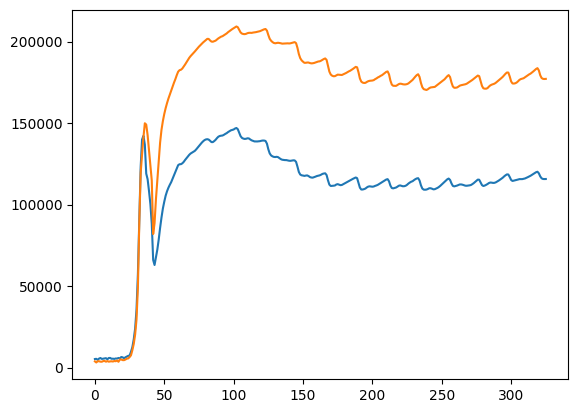

In [6]:
import matplotlib.pyplot as plt
plt.plot(ch1)
plt.plot(ch2)

In [2]:
import asyncio
import threading
import time
from datetime import datetime
from collections import deque

from bleak import BleakClient
import matplotlib.pyplot as plt
%matplotlib qt5

# ------------------------------
# CONFIG
# ------------------------------
DEVICE_ADDRESS = "C4:A3:B2:17:33:F2"
UART_RX_UUID = "6e400003-b5a3-f393-e0a9-e50e24dcca9e"

MAX_POINTS = 500
RUN_TIME_SEC = 60

# ------------------------------
# DATA BUFFERS
# ------------------------------
# t0 = time.time()
t = 0
fs = 200
dt = 1.0 / fs
time_buffer = deque(maxlen=MAX_POINTS)
ch1_buffer  = deque(maxlen=MAX_POINTS)
ch2_buffer  = deque(maxlen=MAX_POINTS)

time_buffer.append(0)

# ------------------------------
# UTILS
# ------------------------------
def timestamp():
    return datetime.now().strftime("%H:%M:%S.%f")[:-3]


# ==============================
# BLE CALLBACK
# ==============================
async def handle_rx(sender, data):
    try:
        text = data.decode("utf-8").strip()
        parts = [int(p) for p in text.split() if p.isdigit()]
        if len(parts) < 2:
            return

        ch, value = parts[0], parts[1]
        # t = time.time() - t0
        t = time_buffer[-1] + dt

        if ch == 1:
            ch1_buffer.append(value)
            ch2_buffer.append(ch2_buffer[-1] if ch2_buffer else value)
        elif ch == 2:
            ch2_buffer.append(value)
            ch1_buffer.append(ch1_buffer[-1] if ch1_buffer else value)
        else:
            print("Unknown channel:", ch)
            return

        time_buffer.append(t)

    except Exception as e:
        print(f"[{timestamp()}] RX error: {e}")


# ==============================
# BLE THREAD
# ==============================
def ble_thread():
    async def run():
        print(f"Connecting to {DEVICE_ADDRESS}...")
        async with BleakClient(DEVICE_ADDRESS) as client:
            if not client.is_connected:
                print("Failed to connect.")
                return

            print("Connected. Receiving data...")
            await client.start_notify(UART_RX_UUID, handle_rx)

            start = time.time()
            while time.time() - start < RUN_TIME_SEC:
                await asyncio.sleep(0.1)

            print("Stopping BLE notifications...")
            await client.stop_notify(UART_RX_UUID)

    asyncio.run(run())


# ==============================
# PLOT LOOP
# ==============================
def plot_loop():
    plt.ion()
    fig, ax = plt.subplots(figsize=(9, 4))

    line1, = ax.plot([], [], label="CH1", lw=2)
    line2, = ax.plot([], [], label="CH2", lw=2)

    ax.set_title("Live BLE Data")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend()

    plt.show()

    while True:
        if len(time_buffer) > 1:
            # time_buffer is 1 longer than ch1_buffer and ch2_buffer
            time_buffer_trimmed = list(time_buffer)[-len(ch1_buffer):]
            line1.set_data(time_buffer_trimmed, ch1_buffer)
            line2.set_data(time_buffer_trimmed, ch2_buffer)

            xmin = max(0, time_buffer[-1] - 5)
            xmax = time_buffer[-1] + 0.1
            ax.set_xlim(xmin, xmax)

            ymin = min(min(ch1_buffer), min(ch2_buffer))
            ymax = max(max(ch1_buffer), max(ch2_buffer))
            if ymin != ymax:
                pad = 0.1 * (ymax - ymin)
                ax.set_ylim(ymin - pad, ymax + pad)

        plt.pause(0.01)


# ==============================
# START EVERYTHING
# ==============================
threading.Thread(target=ble_thread, daemon=True).start()
plot_loop()


Connecting to C4:A3:B2:17:33:F2...
Connected. Receiving data...
Stopping BLE notifications...


KeyboardInterrupt: 

In [1]:
import asyncio
import threading
import time
from datetime import datetime
from collections import deque
import numpy as np

from bleak import BleakClient
import matplotlib.pyplot as plt
%matplotlib qt5

# ------------------------------
# BLE CONFIG
# ------------------------------
DEVICE_ADDRESS = "C4:A3:B2:17:33:F2"
UART_RX_UUID = "6e400003-b5a3-f393-e0a9-e50e24dcca9e"

RUN_TIME_SEC = 60

fs = 200
dt = 1.0 / fs

# ------------------------------
# DATA BUFFERS
# ------------------------------
time_buffer = deque()
ch1_buffer  = deque()
ch2_buffer  = deque()

time_buffer.append(0.0)

# ==============================
# BLE HANDLER
# ==============================
stop_event = threading.Event()

def timestamp():
    return datetime.now().strftime("%H:%M:%S.%f")[:-3]

async def handle_rx(sender, data):
    try:
        text = data.decode("utf-8").strip()
        parts = [int(p) for p in text.split() if p.isdigit()]
        if len(parts) < 2:
            return

        ch, value = parts[0], parts[1]
        t = time_buffer[-1] + dt / 2

        if ch == 1:
            ch1_buffer.append(value)
            ch2_buffer.append(ch2_buffer[-1] if ch2_buffer else value)
        elif ch == 2:
            ch2_buffer.append(value)
            ch1_buffer.append(ch1_buffer[-1] if ch1_buffer else value)
        else:
            return

        time_buffer.append(t)

    except Exception as e:
        print(f"[{timestamp()}] RX error: {e}")

def ble_thread():
    async def run():
        print(f"Connecting to {DEVICE_ADDRESS}...")
        async with BleakClient(DEVICE_ADDRESS) as client:
            if not client.is_connected:
                print("Failed to connect.")
                stop_event.set()
                return

            # The BLE thread obtains new data from the device
            # once an RX notification is given
            print("Connected. Receiving data...")
            await client.start_notify(UART_RX_UUID, handle_rx)

            # Stop after RUN_TIME_SEC seconds
            start = time.time()
            while time.time() - start < RUN_TIME_SEC:
                await asyncio.sleep(0.1)

            print("Stopping BLE notifications...")
            await client.stop_notify(UART_RX_UUID)

        stop_event.set()

    asyncio.run(run())

# ==============================
# PLOT LOOP
# ==============================
def plot_loop():
    plt.ion()
    fig, ax = plt.subplots(figsize=(9, 4))

    line1, = ax.plot([], [], label="CH1", lw=1)
    line2, = ax.plot([], [], label="CH2", lw=1)

    ax.set_title("Live BLE Data")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend()
    plt.show()
    # Terminate plot loop when stop_event is set by the BLE thread
    while not stop_event.is_set():
        if len(time_buffer) > 1:
            t = list(time_buffer)[-len(ch1_buffer):]

            line1.set_data(t, ch1_buffer)
            line2.set_data(t, ch2_buffer)

            ax.set_xlim(max(0, t[-1] - 1), t[-1] + 0.1)

            ymin = min(min(ch1_buffer), min(ch2_buffer))
            ymax = max(max(ch1_buffer), max(ch2_buffer))
            if ymin != ymax:
                pad = 0.1 * (ymax - ymin)
                ax.set_ylim(ymin - pad, ymax + pad)

        plt.pause(0.01)

    plt.ioff()
    plt.close(fig)

    print("Saving data...")

    timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    t_np = np.array(time_buffer)
    ch1_np = np.array(ch1_buffer)
    ch2_np = np.array(ch2_buffer)

    np.savez(
        f"ble_capture_{timestamp_str}.npz",
        time=t_np,
        ch1=ch1_np,
        ch2=ch2_np,
        fs=fs,
    )
    print(f"Saved data at ble_capture_{timestamp_str}.npz")

# Start threads
timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
threading.Thread(target=ble_thread, daemon=True).start()
plot_loop()

# Load and plot saved data
data = np.load(f"ble_capture.npz")
t_np = data["time"]
ch1_np = data["ch1"]
ch2_np = data["ch2"]
t_np = t_np[:len(data["ch1"])]
plt.plot(t_np, ch1_np, label="CH1")
plt.plot(t_np, ch2_np, label="CH2")
plt.legend()
plt.show()
plt.savefig(f"ble_capture.svg")

Connecting to C4:A3:B2:17:33:F2...
Connected. Receiving data...
Stopping BLE notifications...
Saving data...
Saved data at ble_capture_20251229_094326.npz


In [8]:
# Load and plot saved data
data = np.load(f"ble_capture.npz")
t_np = data["time"]
ch1_np = data["ch1"]
ch2_np = data["ch2"]
t_np = t_np[:len(data["ch1"])]
plt.plot(t_np, ch1_np, label="CH1")
plt.plot(t_np, ch2_np, label="CH2")
plt.legend()
plt.show()
plt.savefig(f"ble_capture.svg")